# Water Allocation Simulation Analysis
This notebook provides tools to analyze the results of the water allocation simulation
across multiple scenarios, focusing on ecological and economic impacts under different
conditions.

## Overview
The simulation tests water allocation policies across various scenarios with different:
- River basins (station configurations)
- Actor compositions (different archetypes from the paper)
- Water scarcity levels
- Forecast error profiles (bias and uncertainty)

The analysis evaluates how these factors affect both ecological integrity and economic benefits.


In this notebook we will:
1. Run the set of evaluation scenarios varying station size, scarcity level,  
   forecast bias and uncertainty.
2. Collect ecological and economic impact metrics for each run.
3. Visualize trade-offs and explore how model parameters influence outcomes.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from types import MethodType
import src.core as wms
import src.plot_analysis as gtp
import src.utils as utils
import src.policies.incentive_policies as eip
import src.policies.quota_policies as eqp
import src.scenarios as sc
import src.fast_scenarios as fsc
import src.utils as utils
import src.plot_multi_analysis as pma
import src.policies.custom_policies as cp
from src.policy_regulation import KwargWrapper, PolicyRegulator

# Set better visualization defaults
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:74: ExperimentalWarning:

NSGAIIISampler is experimental (supported from v3.2.0). The interface can change in the future.

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/policy_regulation.py:75: ExperimentalWarning:

QMCSampler is experimental (supported from v3.0.0). The interface can change in the future.



In [8]:
# best_params = {
#     'rate': 1.2391884918766034,
#     'priority_effect': 2.28609153771995848,
#     'crisis_rate': 2.2631005662190557,
#     'max_subvention_weight': -5.0111446274666669,
#     'max_fine_weight': 0.0828160165372797,
#     'policy_rate': 1.700851999736123,
#     'crisis_sensitivity': 3.0909313175279762,
#     'equity_factor': 5.78593358631281,
#     'subsidy_fine_ratio': 0.5772181268749841,
#     'alpha': 0.4401524937396013
# }

In [12]:
pol_reg = PolicyRegulator.from_preoptimized('./saved_polices/ecofair_policies')
best_params = pol_reg.study.trials[46].params
print(best_params)
# TEMP FIX
pol_reg.quota_policy = cp.adaptive_quota
pol_reg.incentives_policy = cp.hard_ecofair_incentives_policy
quota_fn, incentives_fn = pol_reg.get_best_policy_functions(best_params)

{'rate': 2.2150897038028767, 'priority_effect': 0.8609153771995848, 'crisis_rate': 1.260206371941118, 'max_subvention_weight': -0.5111446274666669, 'max_fine_weight': 3.534286719238086, 'policy_rate': 14.851136192778759, 'crisis_sensitivity': 2.2184550766934827, 'equity_factor': 5.78593358631281, 'subsidy_fine_ratio': 0.5772181268749841, 'alpha': 0.22649577519793795}


## Scenario Definition
Runs simulations across the pre-defined scenarios.
We iterate over:
- **Stations**: Tarn vs. La Vézère  
- **Scarcity levels**: low / medium / high  
- **2 set of actors and variant with heterogenous biaises and uncertainties**  
- **Forecast bias/uncertainty** settings  

Execute the next cell to proceed multo-scenario analysis.


## Multi-Scenario Analysis


Save the results if needed.

In [13]:
%%time
if True:
    results_df = fsc.fast_run_all_scenarios(
        turns=700,
        iterations=10,
        custom_incentive_policy = incentives_fn,
        custom_quota = quota_fn,
        max_workers = 16
    )

Starting simulations across all scenarios...
Generating scenarios configurations...
Scenarios configurations complete!
There are 216 unique configurations
Starting simulations
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: -0.25, Uncertainty:0.25, Eco Impact: 0.857, Econ Impact: 0.905, Raw Eco Impact: 1680.0, Cooperation %: 51.2%
Scenario: 1.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty:0.0, Eco Impact: 0.851, Econ Impact: 0.874, Raw Eco Impact: 1668.0, Cooperation %: 49.7%
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.5, Uncertainty:0.25, Eco Impact: 0.862, Econ Impact: 0.906, Raw Eco Impact: 1689.0, Cooperation %: 49.0%
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: -0.25, Uncertainty:0.5, Eco Impact: 0.866, Econ Impact: 0.903, Raw Eco Impact: 1697.0, Cooperation %: 50.0%
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty:0.5, Eco Impact: 0.870, Econ Impact: 0.904, Raw Eco Impact: 1704.0, Cooperation %: 48.6%
Scenario: 0.yml, Station: 1, Scarcity:

In [24]:
%%time

if False:
    results_df = sc.run_all_scenarios(
        turns=700,
        iterations=10,
        custom_incentive_policy = incentives_fn,
        custom_quota = quota_fn,
    )


CPU times: user 0 ns, sys: 2 μs, total: 2 μs
Wall time: 3.81 μs


### Ecological vs. economic impact.

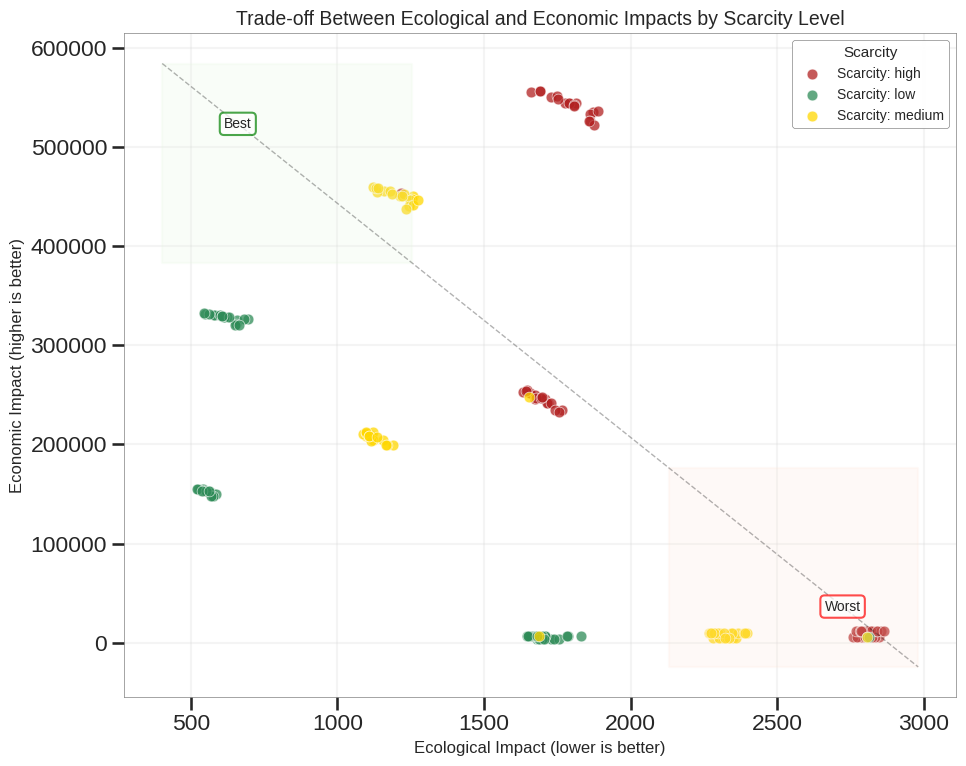

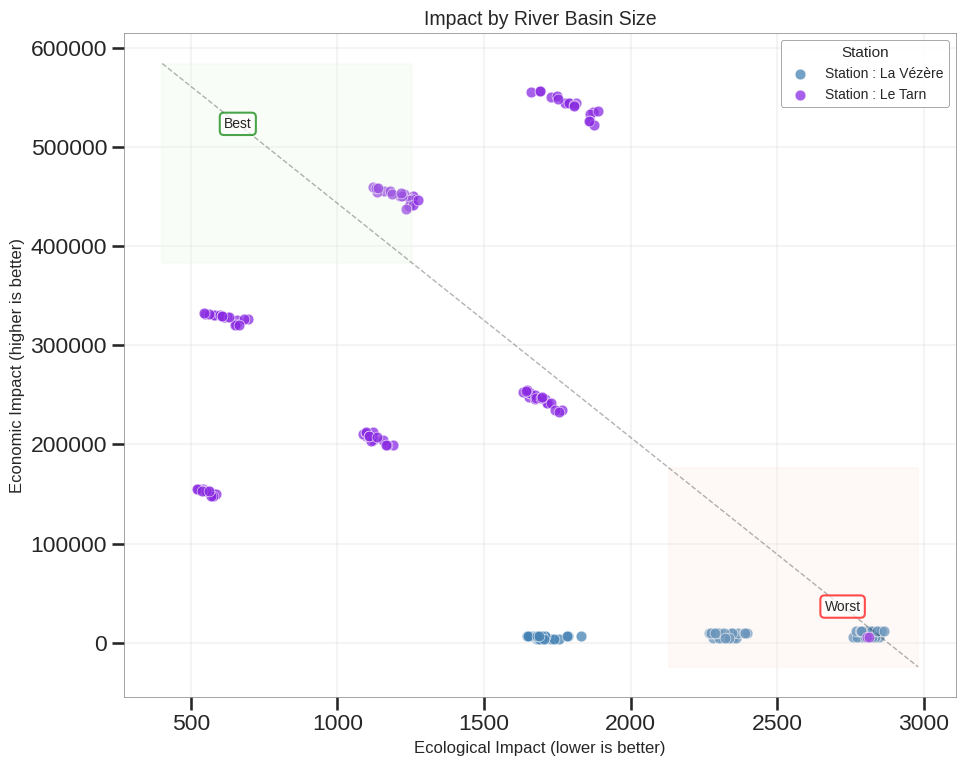

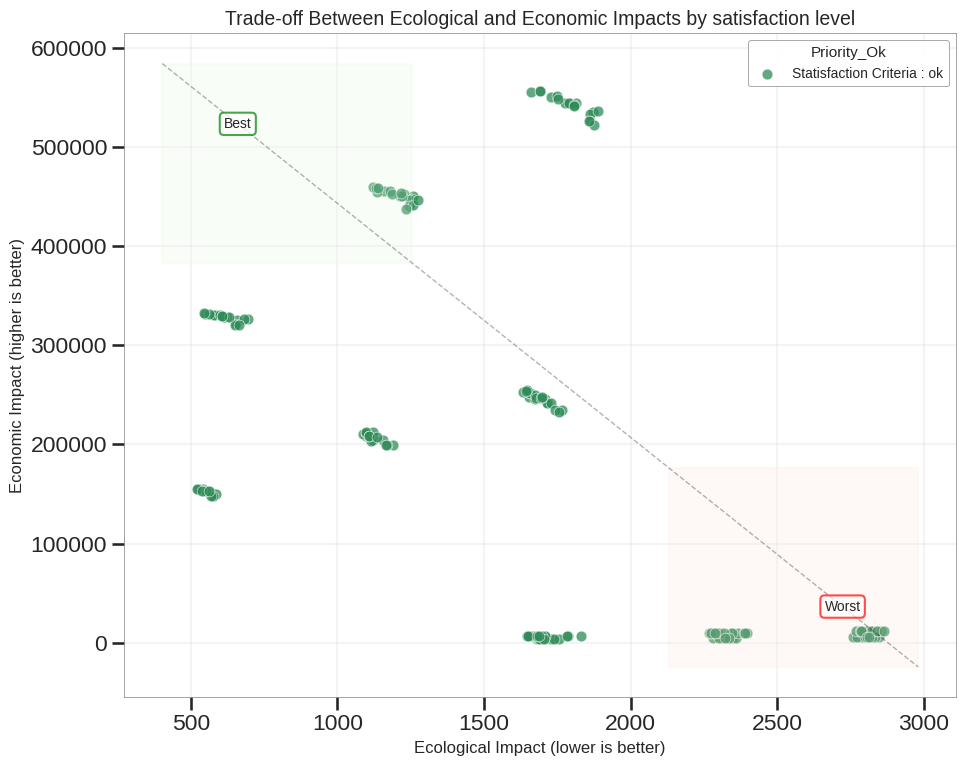

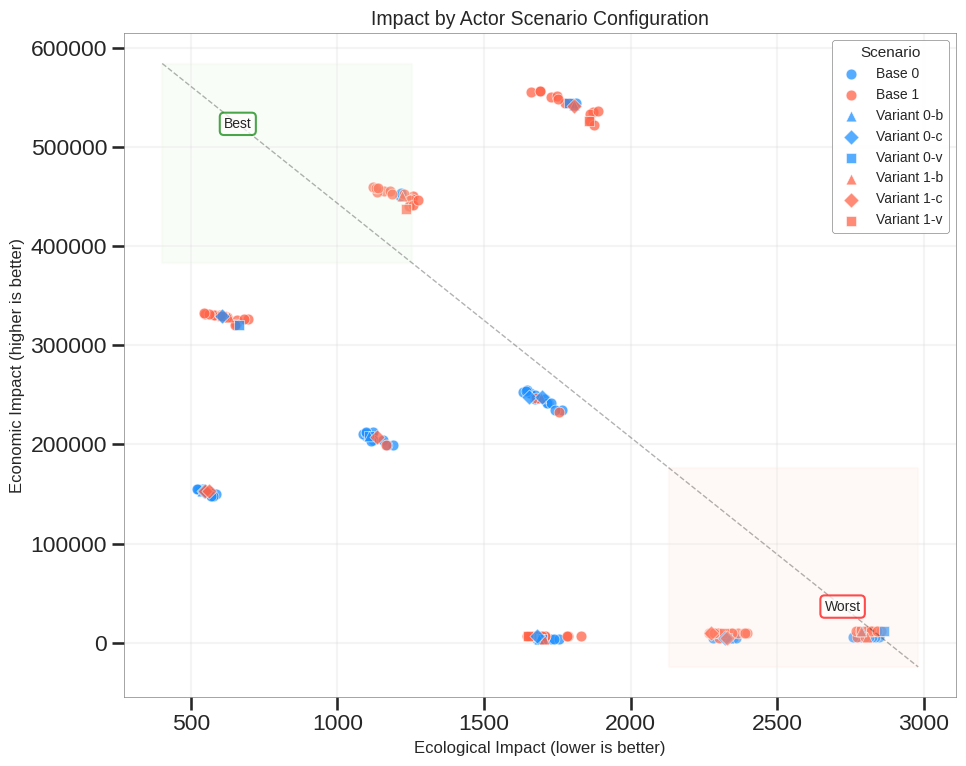

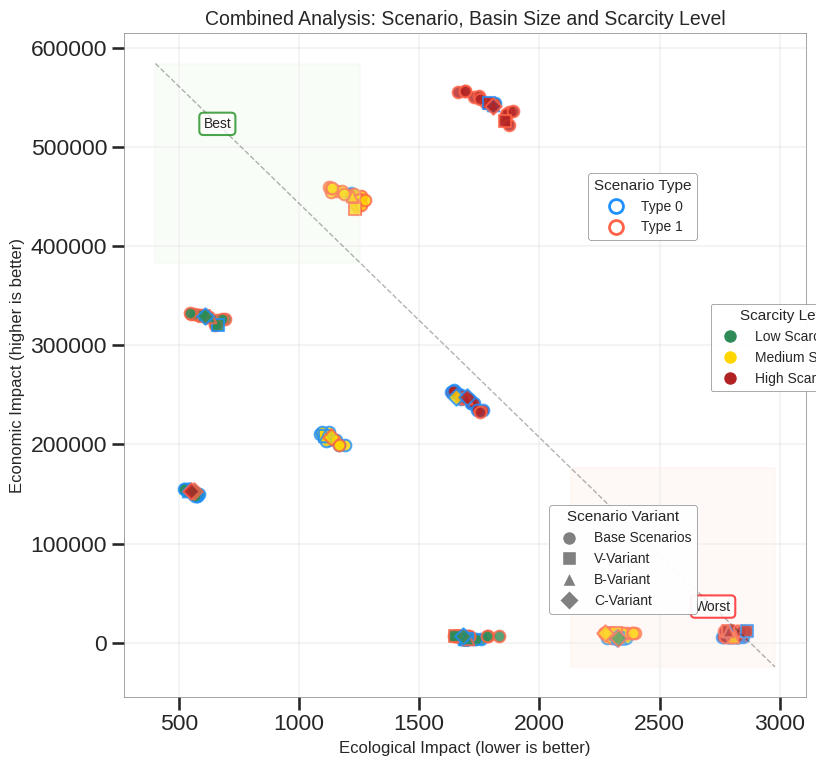

In [14]:
pma.analyze_scenario_impacts(results_df)

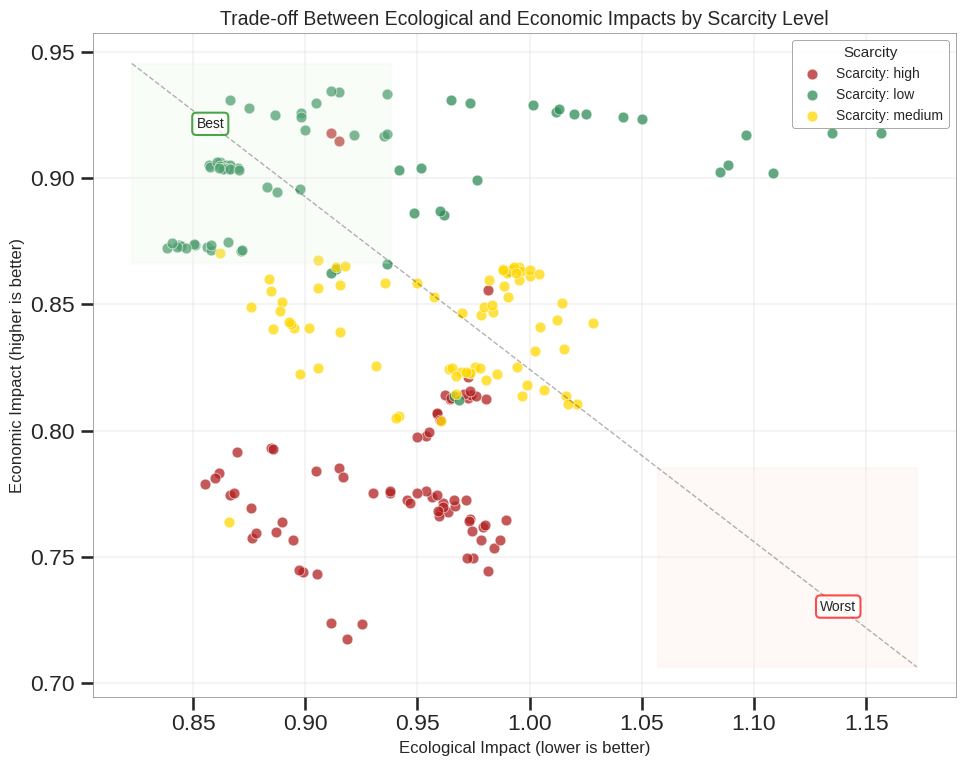

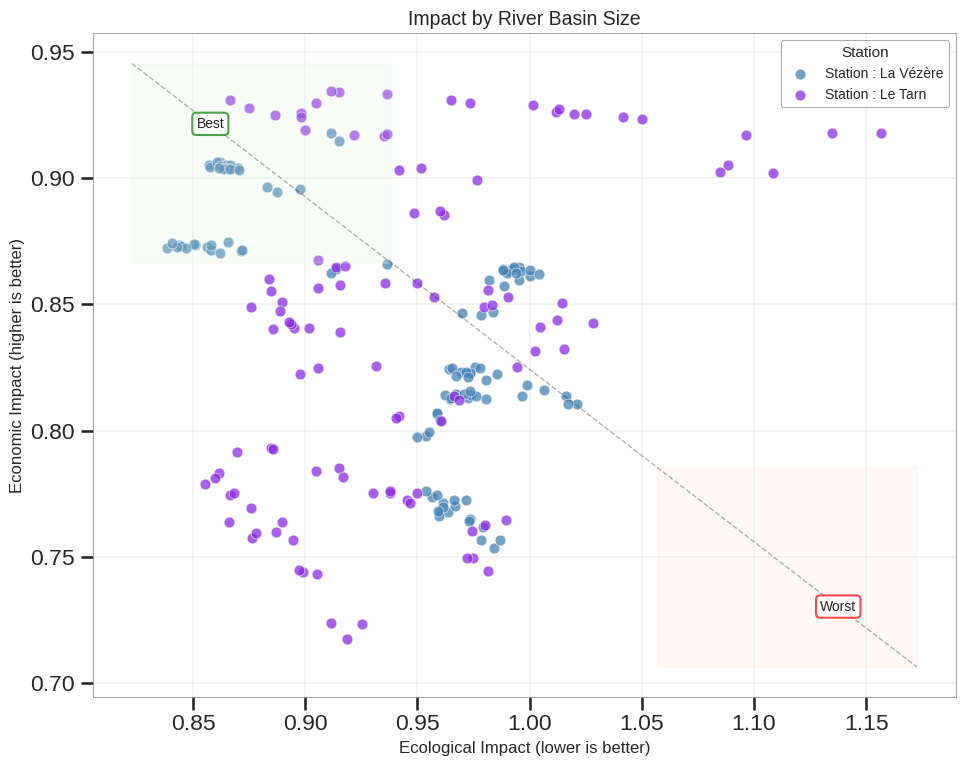

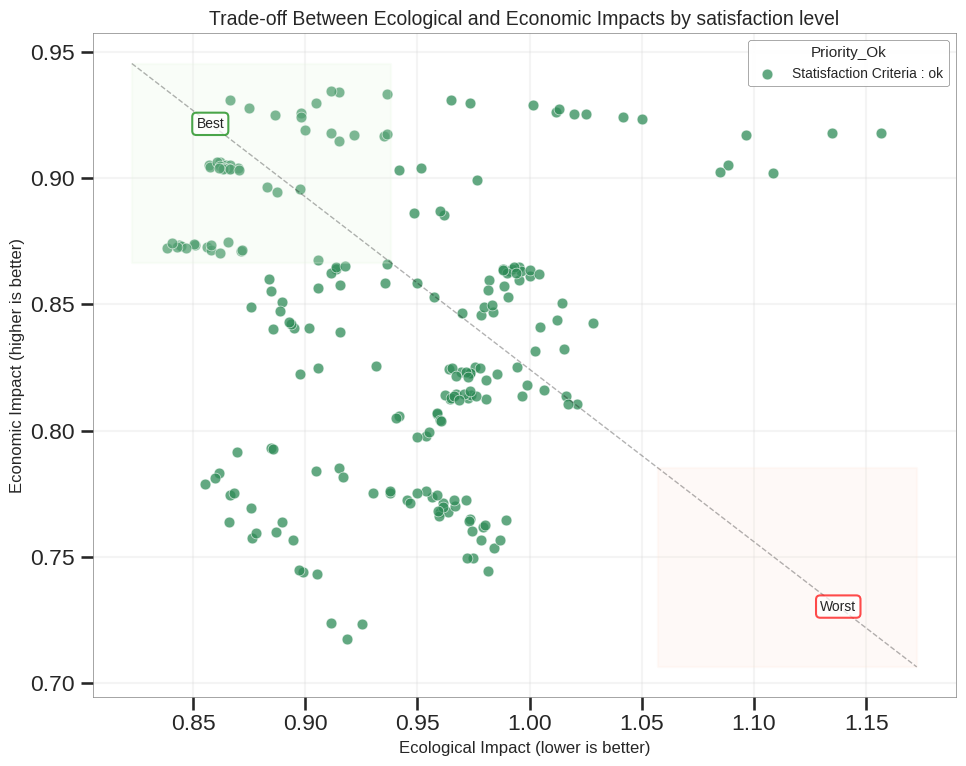

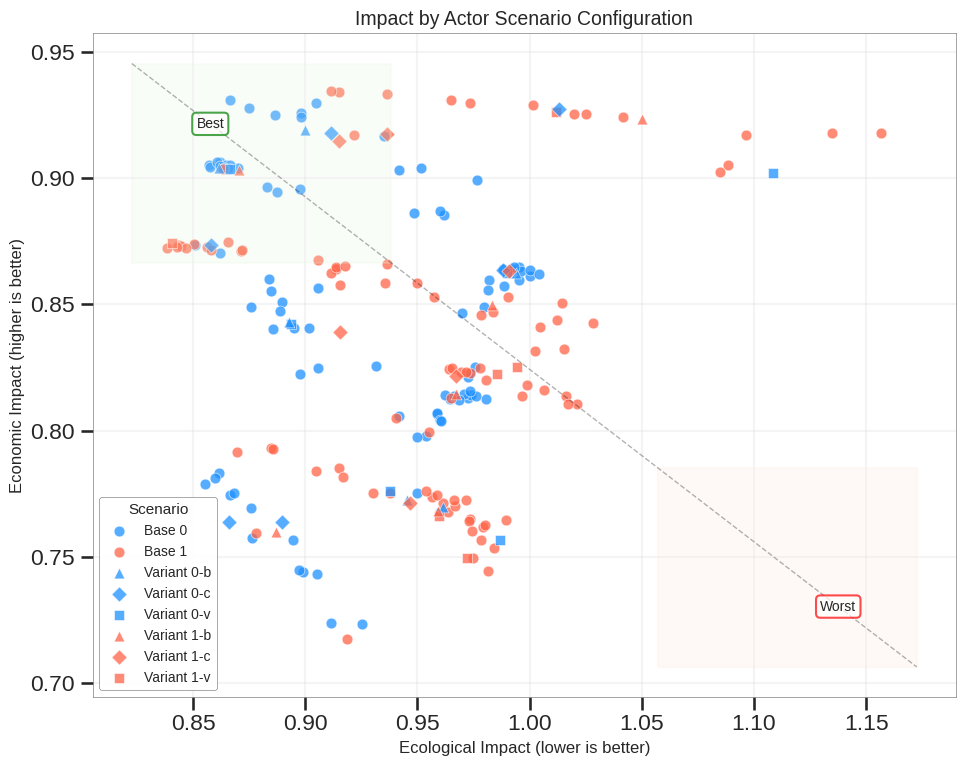

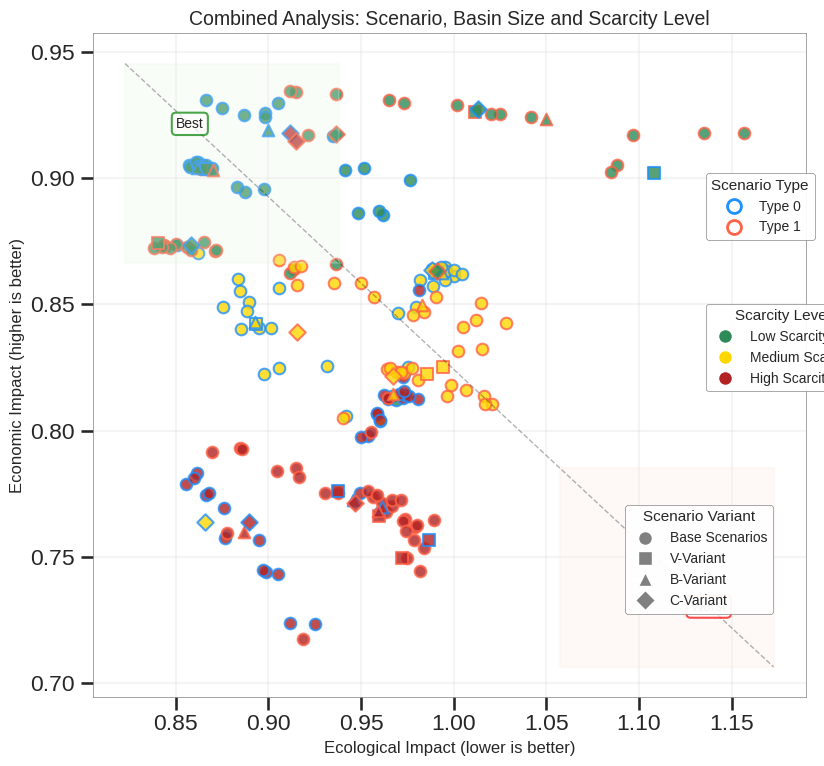

In [15]:
pma.analyze_scenario_impacts(results_df, is_scalled = True)

## Analyzing Forecast Bias & Uncertainty & Scarcity levels

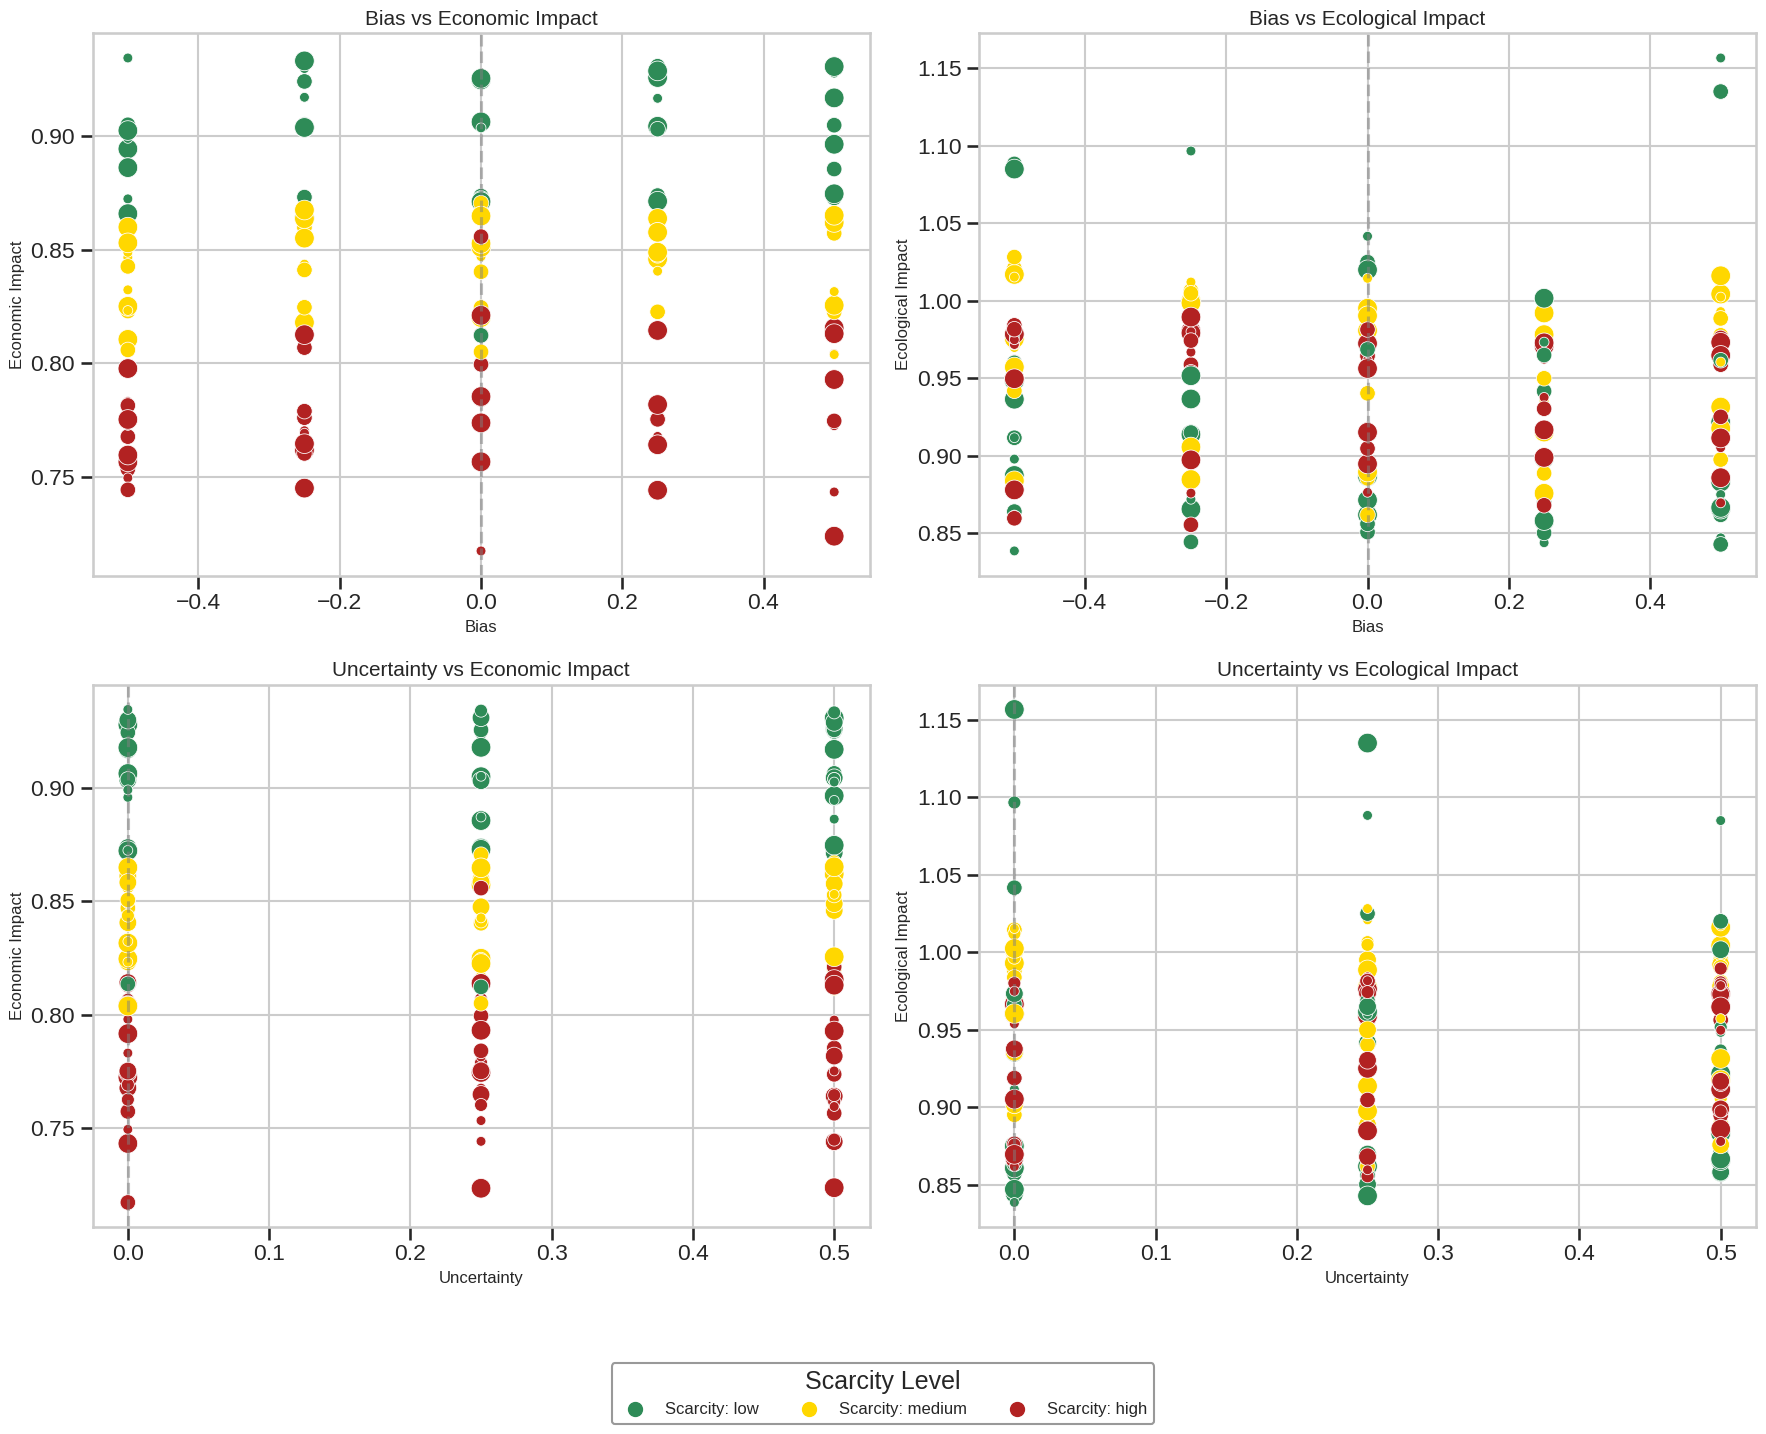

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:351: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:351: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




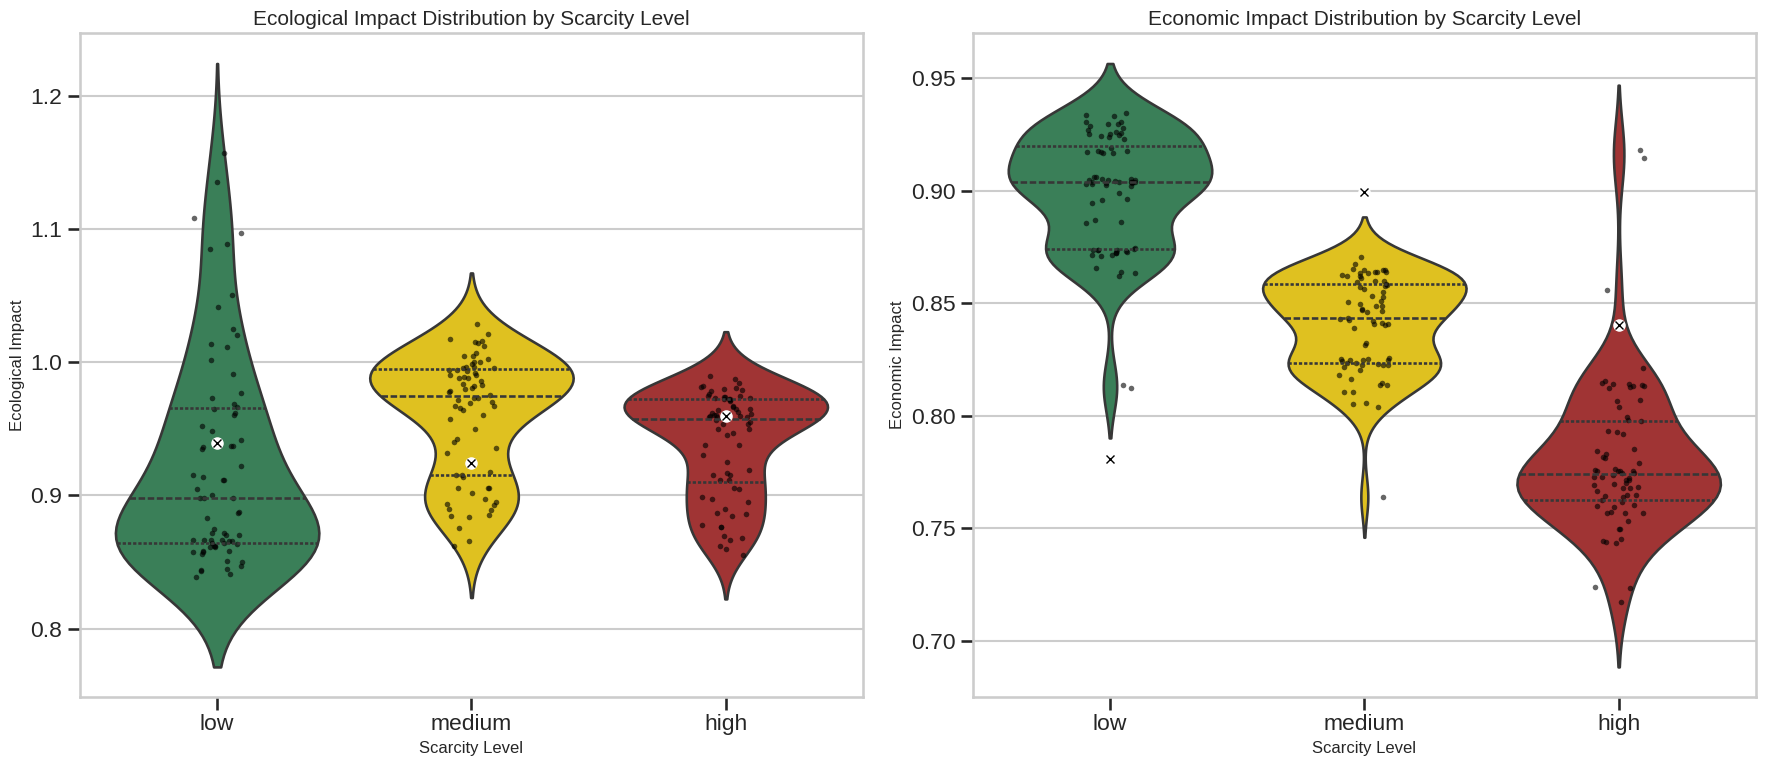

In [16]:
pma.analyze_forecast_effects(results_df, is_scalled = True)

## Correlation Analysis


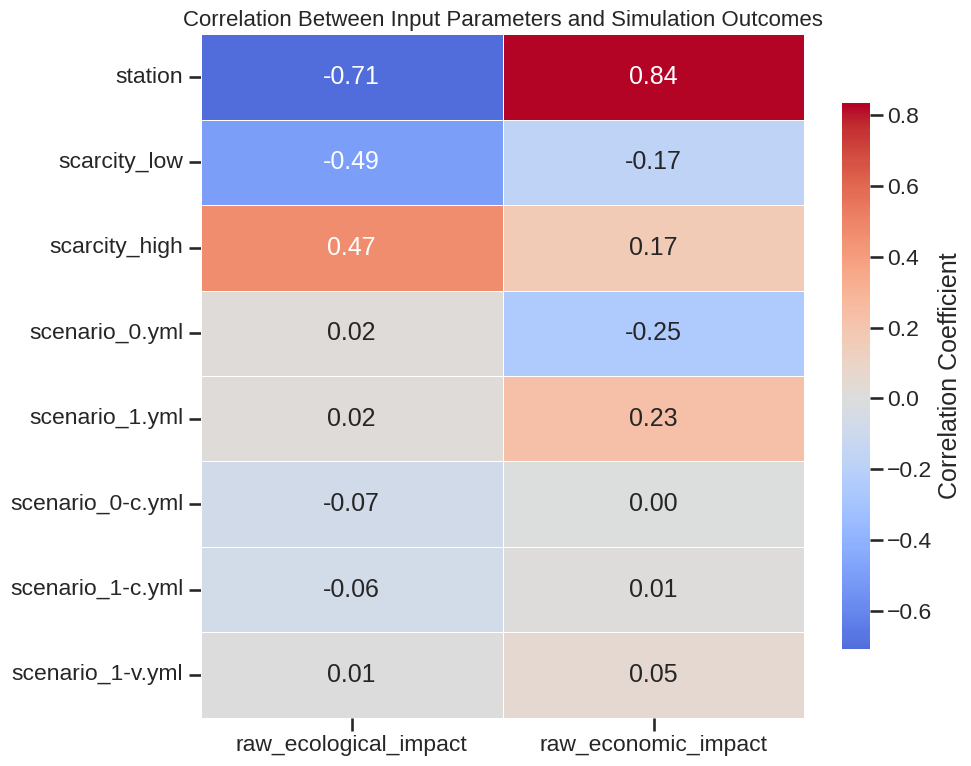


Top impacts on raw_ecological_impact:

Top 5 positive correlations:
  scarcity_high: 0.466
  scarcity_medium: 0.027
  scenario_1-b.yml: 0.020
  scenario_1.yml: 0.019
  scenario_0.yml: 0.016

Top 5 negative correlations:
  bias: -0.011
  scenario_1-c.yml: -0.064
  scenario_0-c.yml: -0.070
  scarcity_low: -0.494
  station: -0.709

Top impacts on raw_economic_impact:

Top 5 positive correlations:
  station: 0.836
  scenario_1.yml: 0.226
  scarcity_high: 0.170
  scenario_1-v.yml: 0.052
  scenario_0-v.yml: 0.017

Top 5 negative correlations:
  scenario_0-b.yml: -0.009
  uncertainty: -0.013
  bias: -0.014
  scarcity_low: -0.174
  scenario_0.yml: -0.254


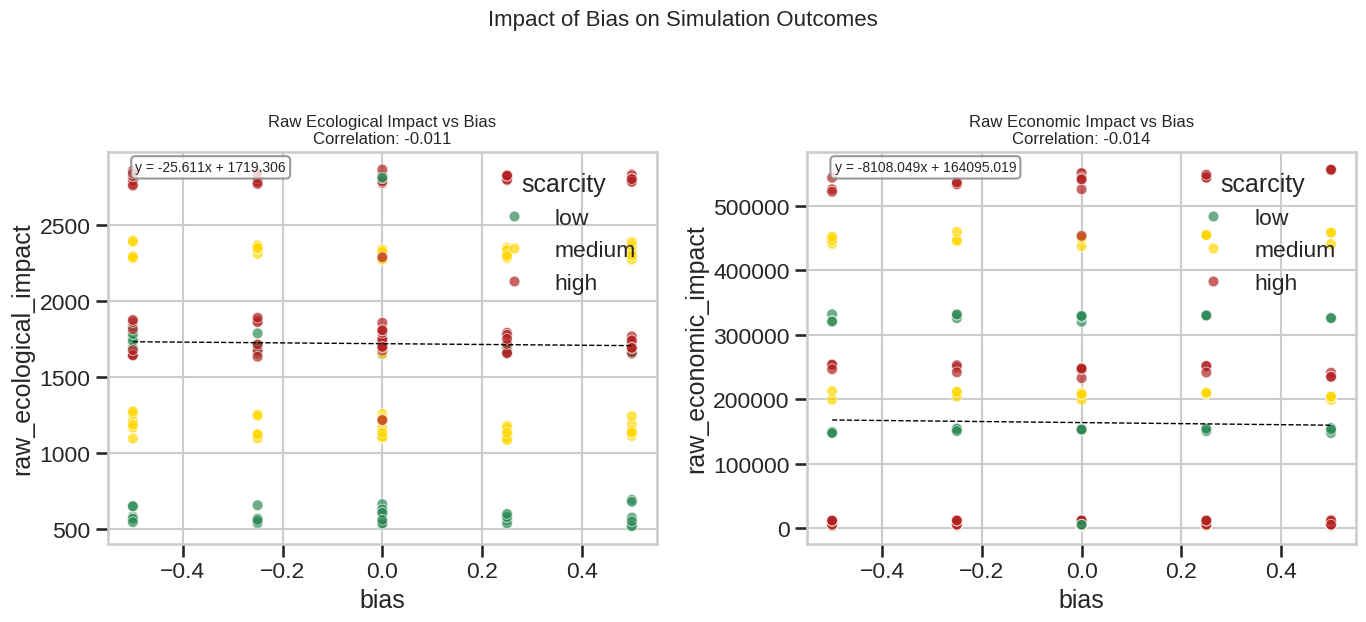

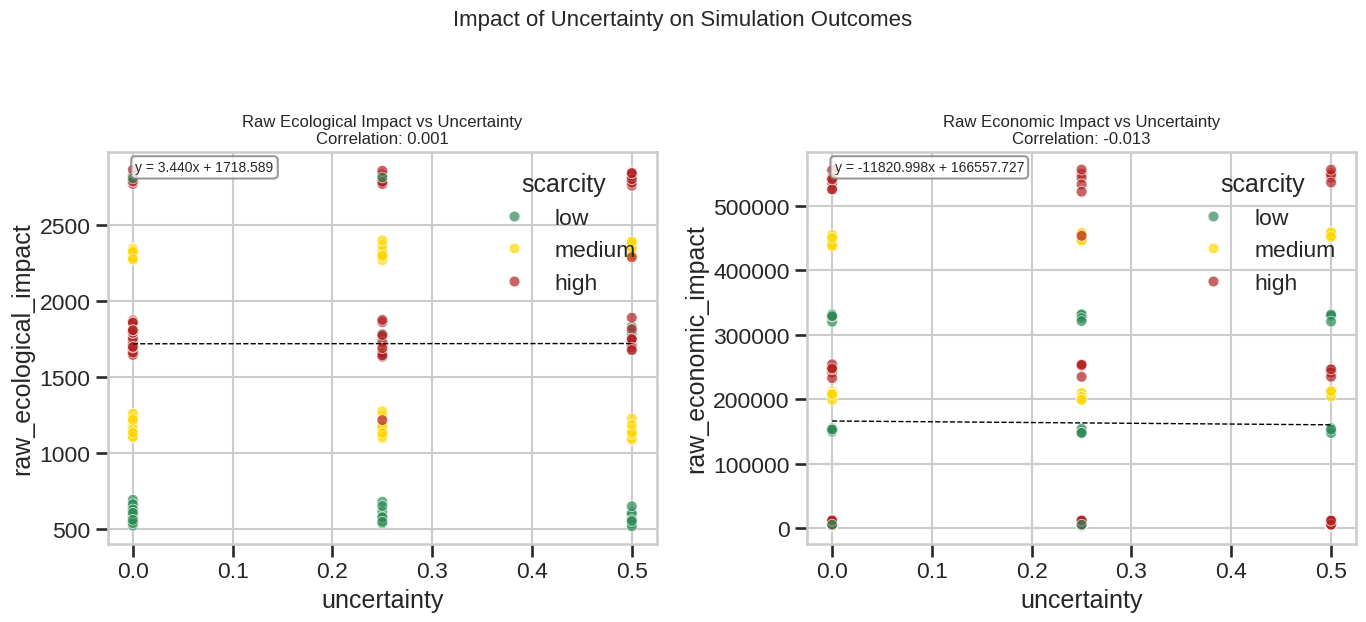

<Figure size 1200x1000 with 0 Axes>

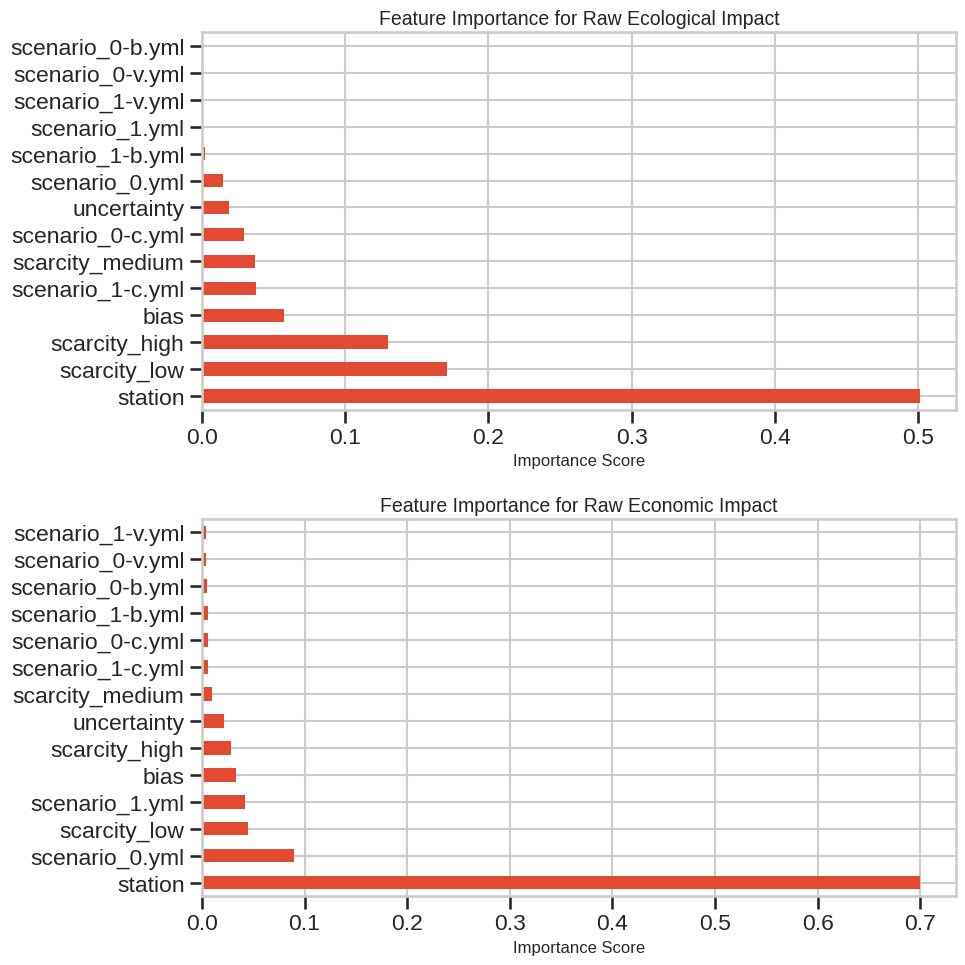

In [17]:
pma.correlation_analysis(results_df)

## Cooperation Analysis
Analyzing cooperation patterns across scenarios and their impact on ecological and economic outcomes.

/mnt/c/users/oluwa/OneDrive_V2/OneDrive/Competitions/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:991: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




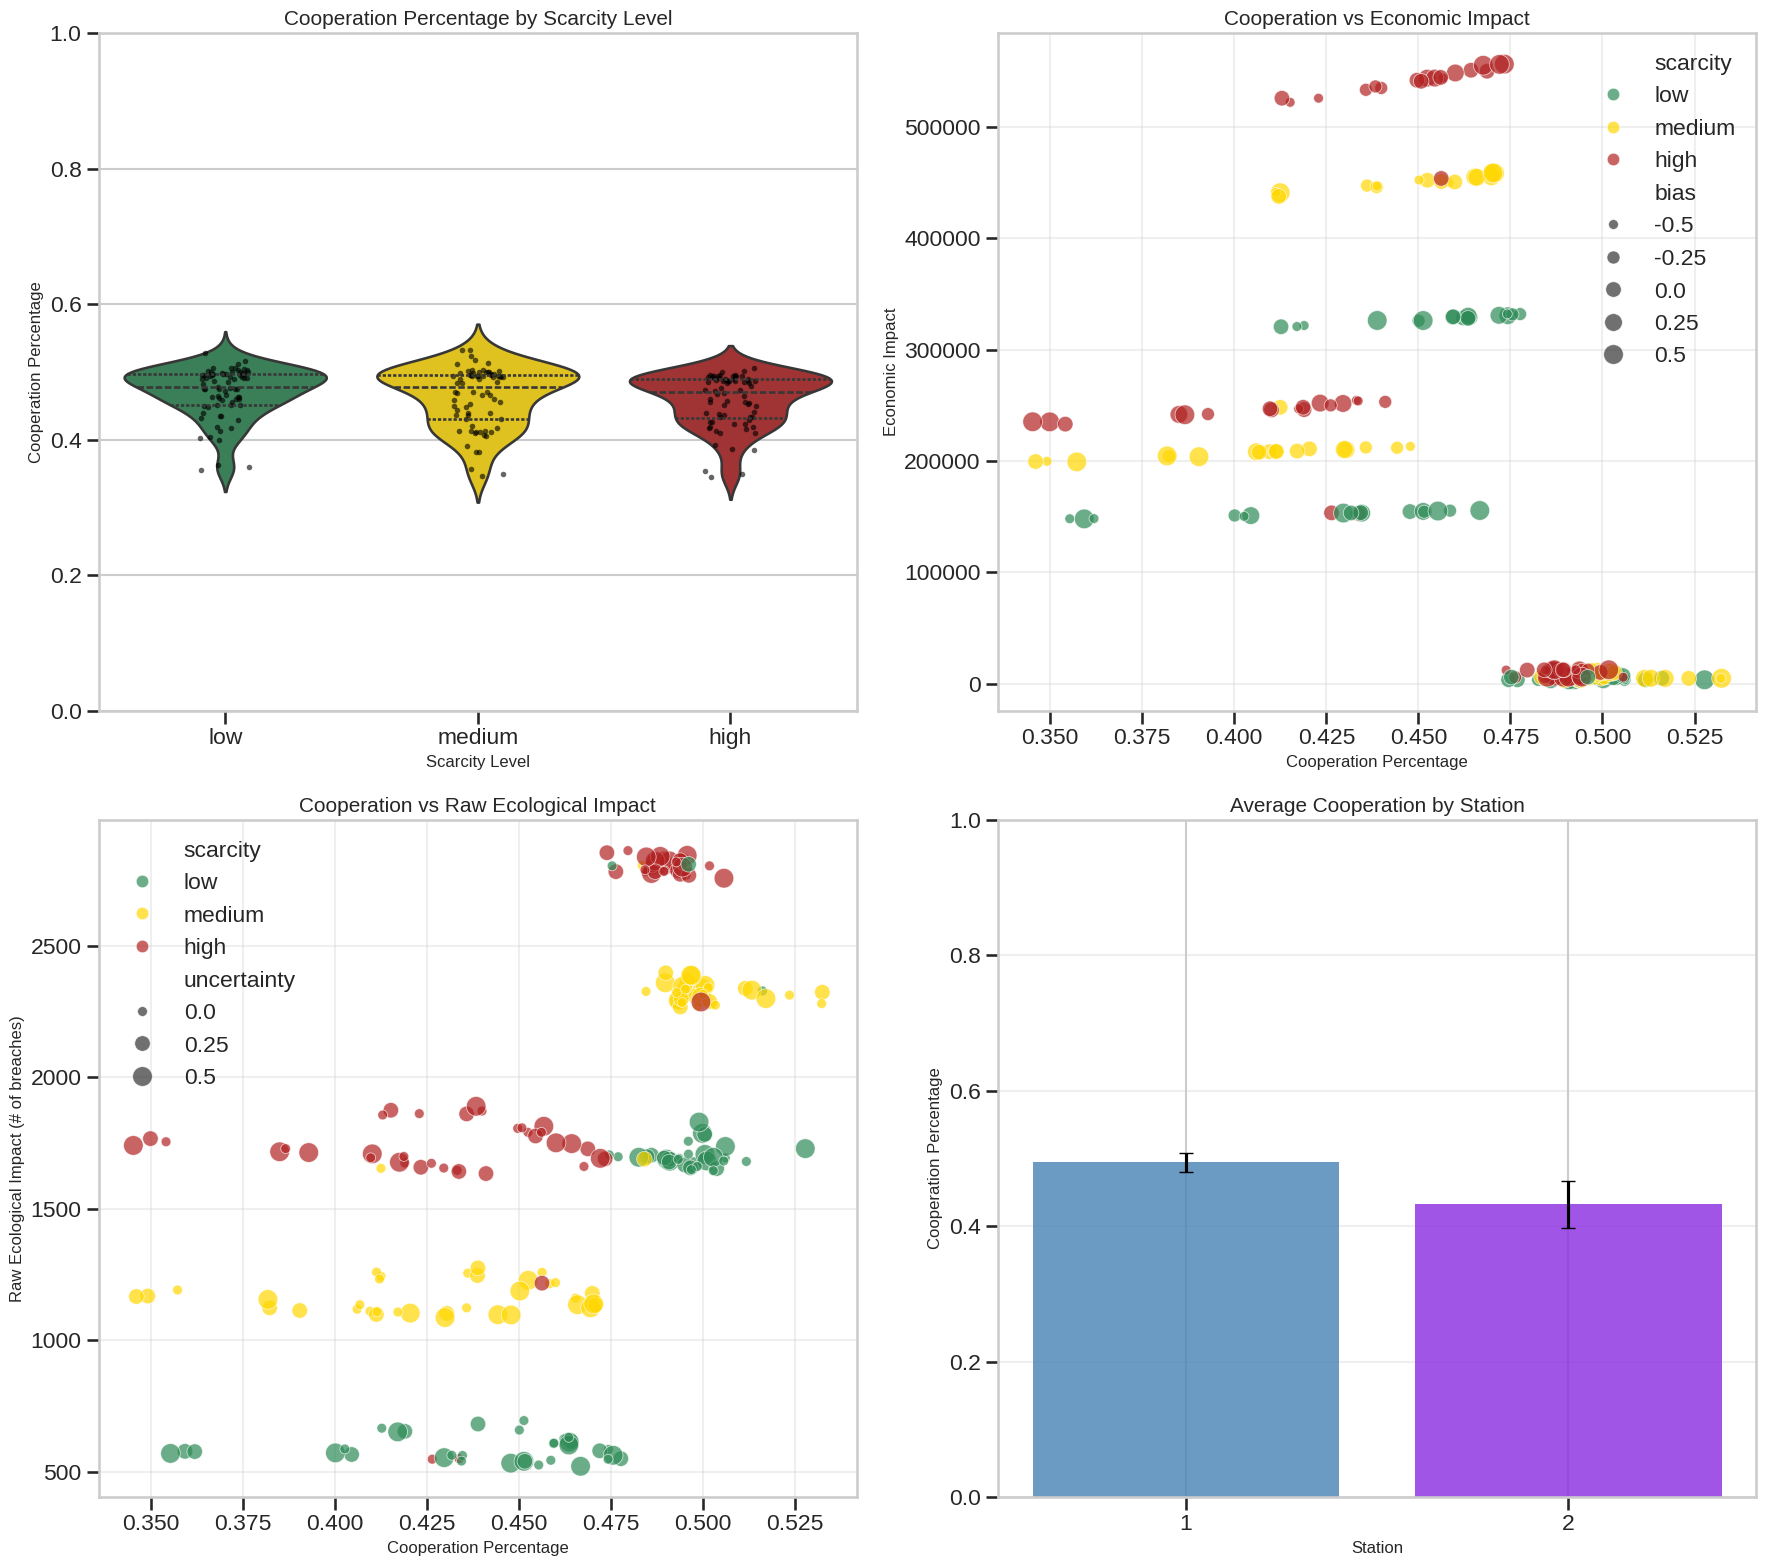

In [18]:
pma.analyze_cooperation_patterns(results_df)

## Raw Impact vs Scaled Impact
Analyzing the raw (unscaled) ecological impact across different scenarios.

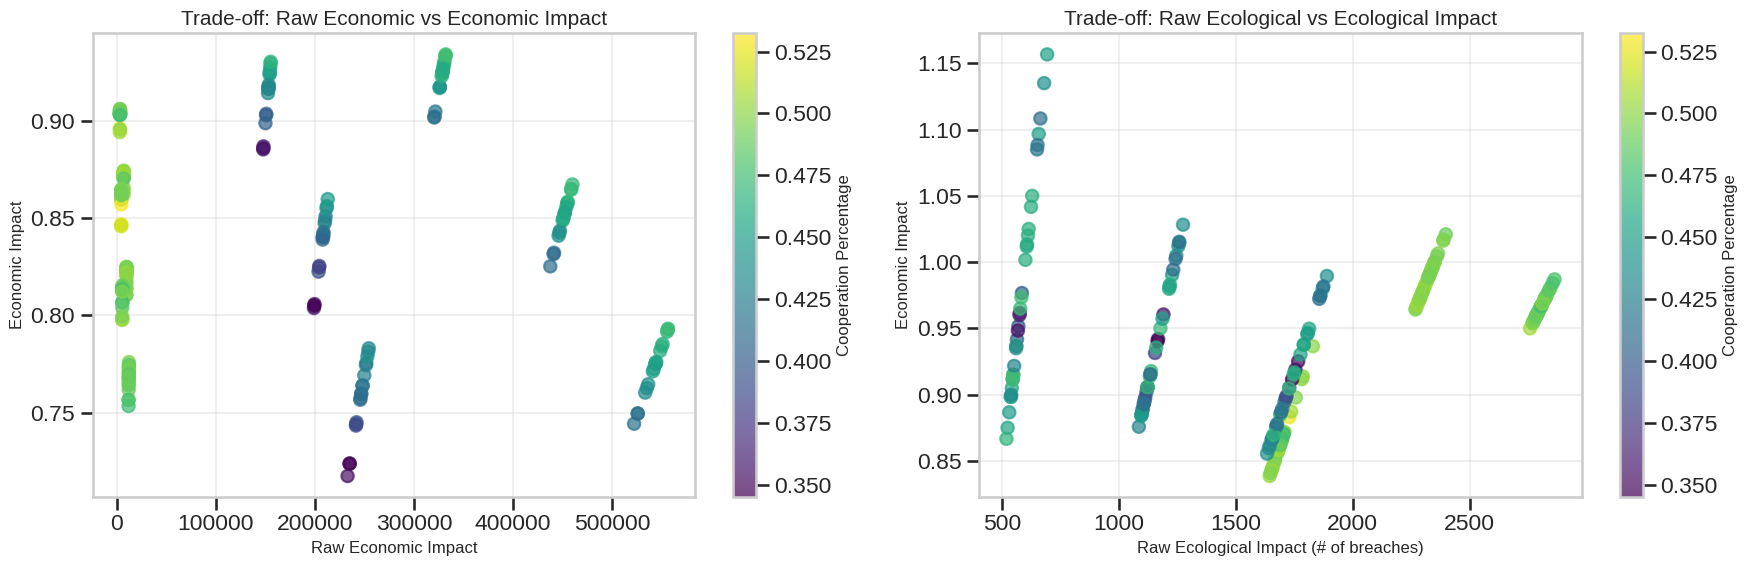

In [19]:
pma.analyze_raw_impact(results_df)

## Cooperation by Forecast Parameters
Analyzing how forecast bias and uncertainty affect cooperation levels.


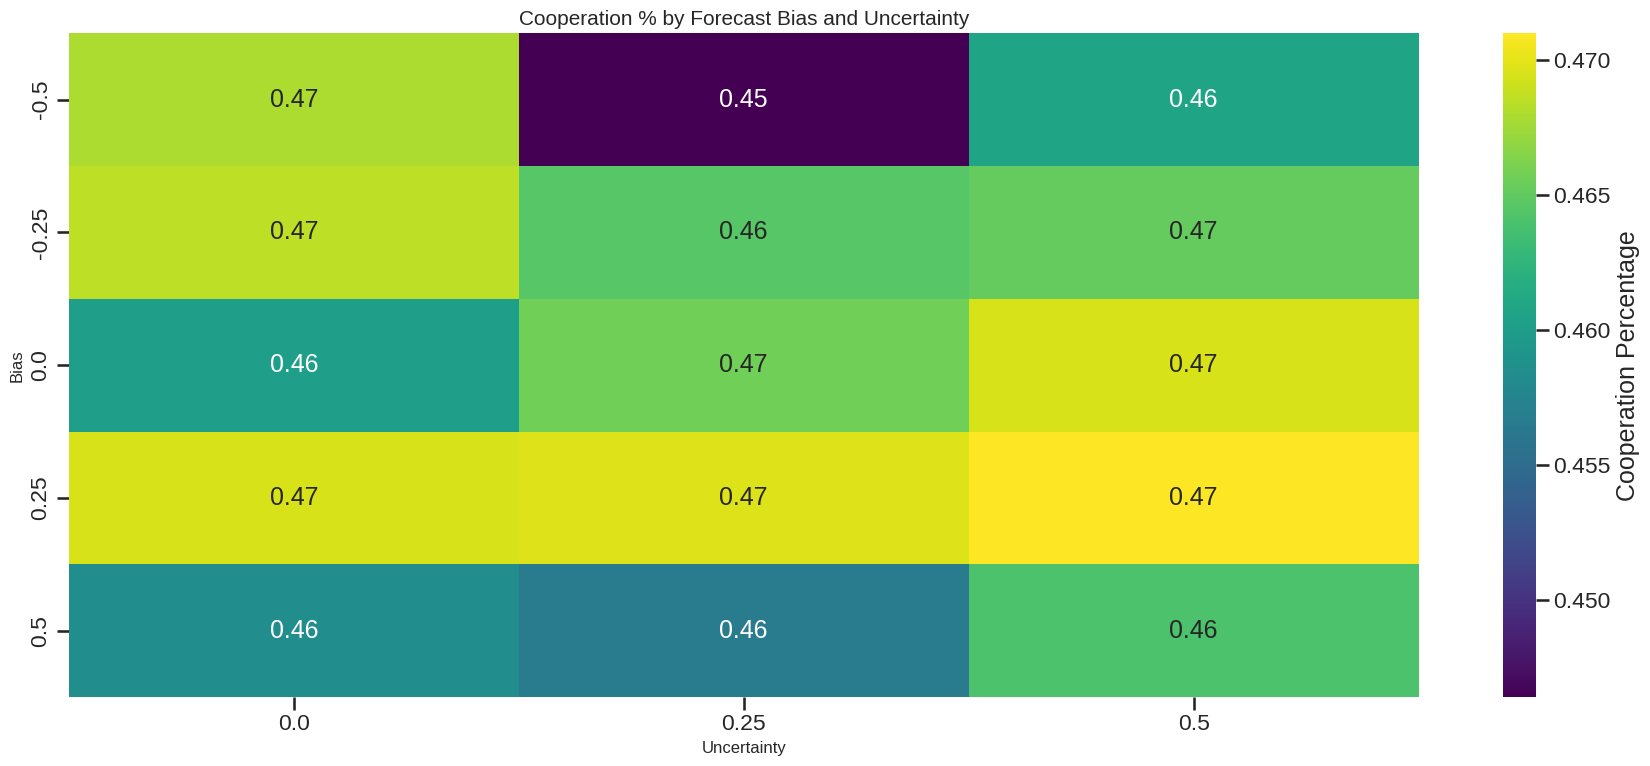

In [20]:
pma.analyze_cooperation_by_forecast_params(results_df)

## Comprehensive Analysis
Performing a comprehensive analysis of all metrics and their relationships.


In [21]:
results_df.priority_ok.mean()

1.0

=== Summary Statistics ===

Overall Metrics:
Average Cooperation: 0.46
Average Raw Ecological Impact: 1719.3 breaches
Average Scaled Ecological Impact: 0.941
Average Economic Impact: 0.840

Correlation Matrix:
                        cooperation_percentage  raw_ecological_impact  \
cooperation_percentage                    1.00                   0.55   
raw_ecological_impact                     0.55                   1.00   
ecological_impact                         0.03                   0.12   
economic_impact                           0.18                  -0.62   
raw_economic_impact                      -0.52                  -0.52   
bias                                      0.02                  -0.01   
uncertainty                               0.02                   0.00   

                        ecological_impact  economic_impact  \
cooperation_percentage               0.03             0.18   
raw_ecological_impact                0.12            -0.62   
ecological_impact  

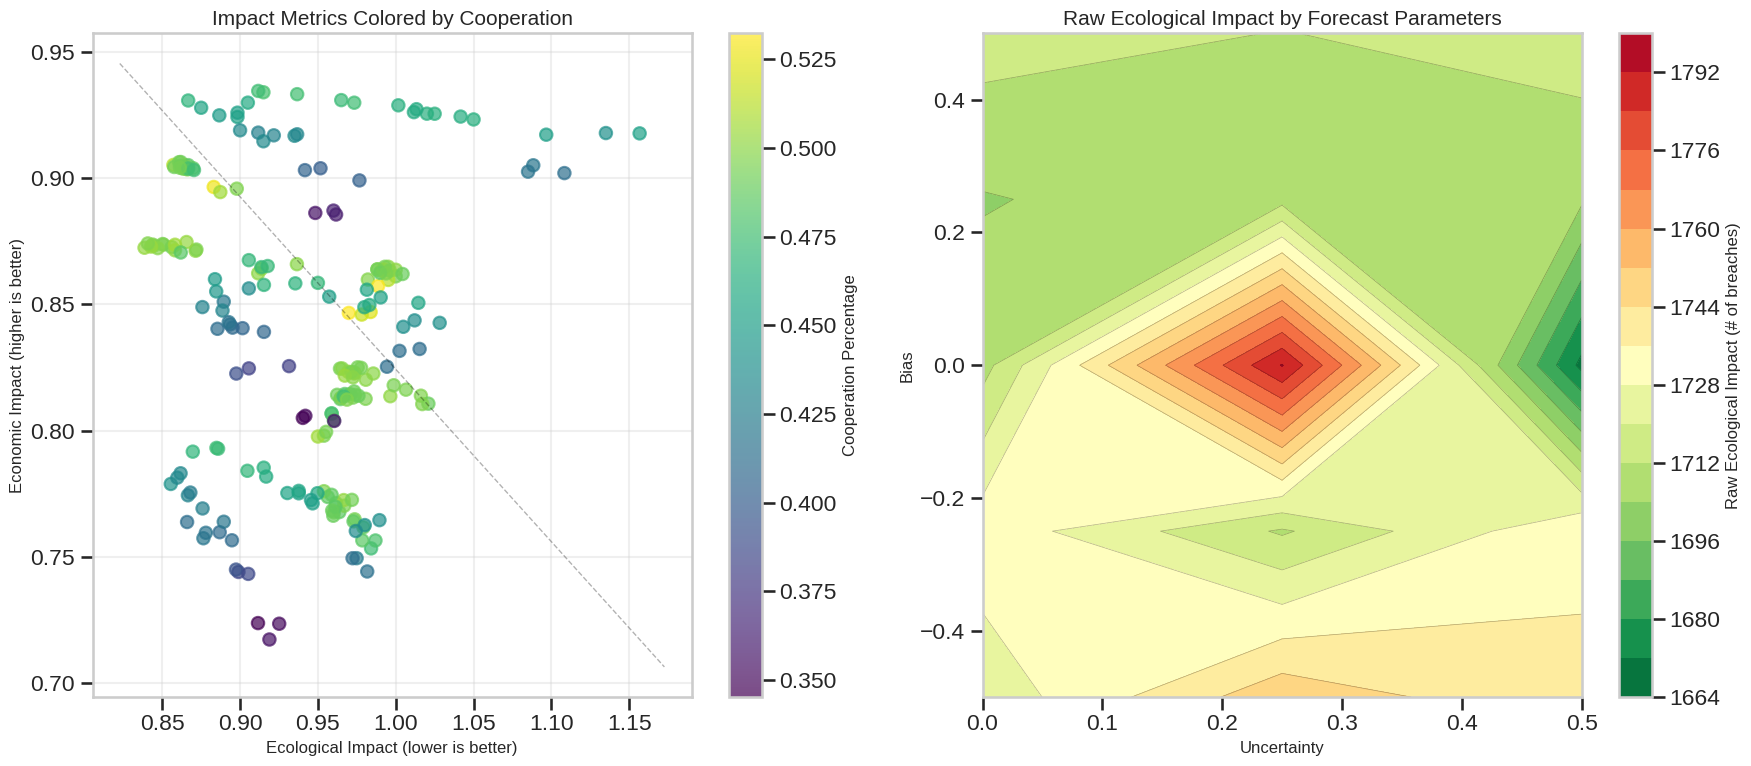

In [22]:
pma.comprehensive_analysis(results_df, is_scalled = True)

## Conclusion
This notebook has demonstrated how to analyze water allocation policies across multiple scenarios,
focusing on the balance between ecological and economic impacts. To participate in the hackathon:

1. Design your own adaptive policy by modifying the `custom_incentive_policy` and `custom_quota` functions
2. Test your policy across multiple scenarios using the tools provided
3. Optimize your policy to balance ecological integrity and economic benefits

Good luck!